# Tutorial: MLP para clasificacion con CIFAR-10 (Keras)

En este cuaderno entrenaremos dos modelos MLP (perceptron multicapa) para clasificacion de imagenes en CIFAR-10:

1. Modelo base sin regularizacion.
2. Modelo con regularizacion (L2 + Dropout + BatchNormalization + EarlyStopping).

Compararemos:
- Curvas de entrenamiento y test (accuracy y loss).
- Matriz de confusion.
- Metricas tipicas de evaluacion.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

import keras
from keras import layers, regularizers

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
keras.utils.set_random_seed(SEED)

print("Keras version:", keras.__version__)
print("Backend activo:", keras.backend.backend())


Keras version: 3.10.0
Backend activo: tensorflow


In [2]:
# Cargar CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape, "y_test :", y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
x_train: (50000, 32, 32, 3) y_train: (50000,)
x_test : (10000, 32, 32, 3) y_test : (10000,)


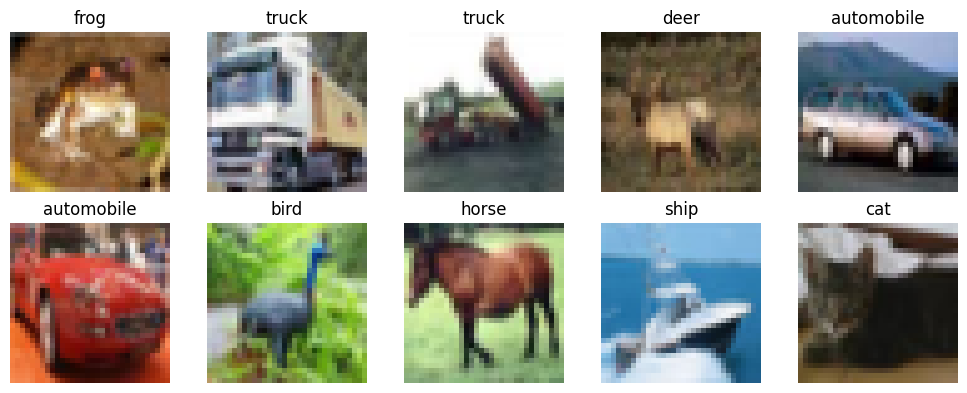

In [3]:
# Visualizar algunas imagenes del dataset
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [27]:
# Preprocesado para MLP: normalizar y aplanar
x_train_mlp = x_train.astype("float32") / 255.0
x_test_mlp = x_test.astype("float32") / 255.0

x_train_mlp = x_train_mlp.reshape(len(x_train_mlp), -1)
x_test_mlp = x_test_mlp.reshape(len(x_test_mlp), -1)

input_dim = x_train_mlp.shape[1]
num_classes = 10

print("Input dimension para MLP:", input_dim)



Input dimension para MLP: 3072


## Utilidades para entrenamiento y evaluacion


In [5]:
def plot_history(history, title):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, hist["loss"], label="train loss")
    axes[0].plot(epochs, hist["val_loss"], label="test loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, hist["accuracy"], label="train acc")
    axes[1].plot(epochs, hist["val_accuracy"], label="test acc")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, x_test, y_test, class_names, title):
    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1w = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    f1m = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"=== {title} ===")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision weighted: {prec:.4f}")
    print(f"Recall weighted   : {rec:.4f}")
    print(f"F1 weighted       : {f1w:.4f}")
    print(f"F1 macro          : {f1m:.4f}")

    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=False)
    plt.title(f"Matriz de confusion - {title}")
    plt.tight_layout()
    plt.show()


## 1) Modelo base sin regularizacion


In [28]:

model_base = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    )
    

model_base.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
EPOCHS = 30
BATCH_SIZE = 1024

history_base = model_base.fit(
    x_train_mlp, y_train,
    validation_data=(x_test_mlp, y_test),  # curvas train/test
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)


Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.1645 - loss: 2.5089 - val_accuracy: 0.3271 - val_loss: 1.9091
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3336 - loss: 1.8905 - val_accuracy: 0.3661 - val_loss: 1.8168
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3695 - loss: 1.7972 - val_accuracy: 0.3775 - val_loss: 1.7638
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3901 - loss: 1.7275 - val_accuracy: 0.3948 - val_loss: 1.7123
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4053 - loss: 1.6806 - val_accuracy: 0.4175 - val_loss: 1.6596
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4199 - loss: 1.6387 - val_accuracy: 0.4272 - val_loss: 1.6305
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4330 - loss: 1.6031 - val_accuracy: 0.4322 - val_loss: 1.6051
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4433 - loss: 1.5710 - val_accuracy: 0.4423 - v

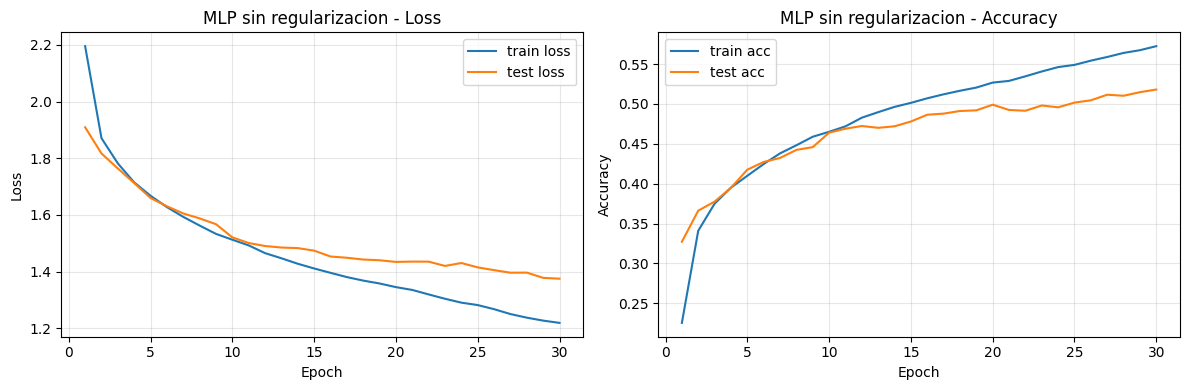

=== MLP sin regularizacion ===
Accuracy          : 0.5180
Precision weighted: 0.5111
Recall weighted   : 0.5180
F1 weighted       : 0.5098
F1 macro          : 0.5098
Classification report:
              precision    recall  f1-score   support

    airplane     0.5522    0.6140    0.5814      1000
  automobile     0.5770    0.6780    0.6234      1000
        bird     0.4374    0.3700    0.4009      1000
         cat     0.3892    0.2670    0.3167      1000
        deer     0.4686    0.4400    0.4538      1000
         dog     0.4399    0.3990    0.4185      1000
        frog     0.5921    0.5370    0.5632      1000
       horse     0.5520    0.6160    0.5822      1000
        ship     0.5236    0.7550    0.6183      1000
       truck     0.5793    0.5040    0.5390      1000

    accuracy                         0.5180     10000
   macro avg     0.5111    0.5180    0.5098     10000
weighted avg     0.5111    0.5180    0.5098     10000



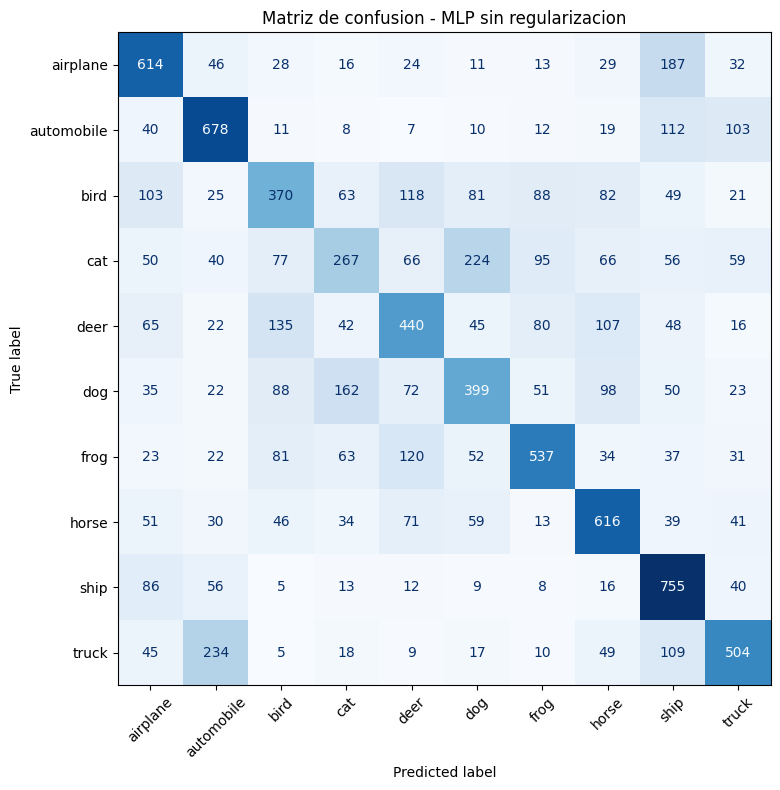

In [30]:
plot_history(history_base, "MLP sin regularizacion")
evaluate_model(model_base, x_test_mlp, y_test, class_names, "MLP sin regularizacion")


## 2) Modelo con regularizacion

Se aplican varias tecnicas:
- L2 en capas densas.
- BatchNormalization.
- Dropout.
- EarlyStopping para evitar sobreentrenamiento.


In [ ]:
num_classes=10
l2_lambda=1e-3



model_reg = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(num_classes, activation="softmax"),
    ])

model_reg.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
  


model_reg.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 30
BATCH_SIZE = 1024
history_reg = model_reg.fit(
    x_train_mlp, y_train,
    validation_data=(x_test_mlp, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)


Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5487 - loss: 1.4100 - val_accuracy: 0.5189 - val_loss: 1.4919
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5499 - loss: 1.4029 - val_accuracy: 0.5198 - val_loss: 1.4953
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5482 - loss: 1.4088 - val_accuracy: 0.5052 - val_loss: 1.5348
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5504 - loss: 1.4069 - val_accuracy: 0.5043 - val_loss: 1.5233
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5496 - loss: 1.4027 - val_accuracy: 0.5118 - val_loss: 1.5096


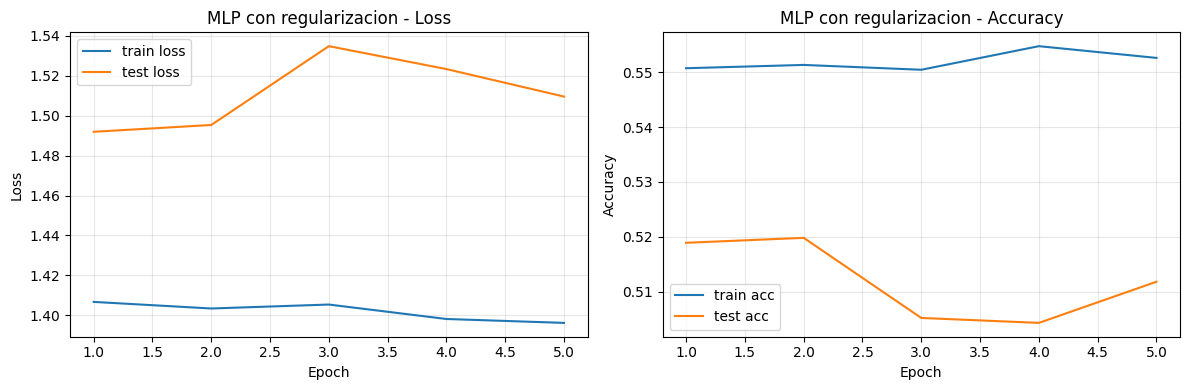

=== MLP con regularizacion ===
Accuracy          : 0.5118
Precision weighted: 0.5226
Recall weighted   : 0.5118
F1 weighted       : 0.5069
F1 macro          : 0.5069
Classification report:
              precision    recall  f1-score   support

    airplane     0.5501    0.6040    0.5758      1000
  automobile     0.7034    0.5550    0.6205      1000
        bird     0.4591    0.2750    0.3440      1000
         cat     0.3569    0.3840    0.3699      1000
        deer     0.4006    0.5420    0.4607      1000
         dog     0.4717    0.3840    0.4234      1000
        frog     0.6602    0.4060    0.5028      1000
       horse     0.5747    0.5730    0.5739      1000
        ship     0.5383    0.7160    0.6146      1000
       truck     0.5109    0.6790    0.5831      1000

    accuracy                         0.5118     10000
   macro avg     0.5226    0.5118    0.5069     10000
weighted avg     0.5226    0.5118    0.5069     10000



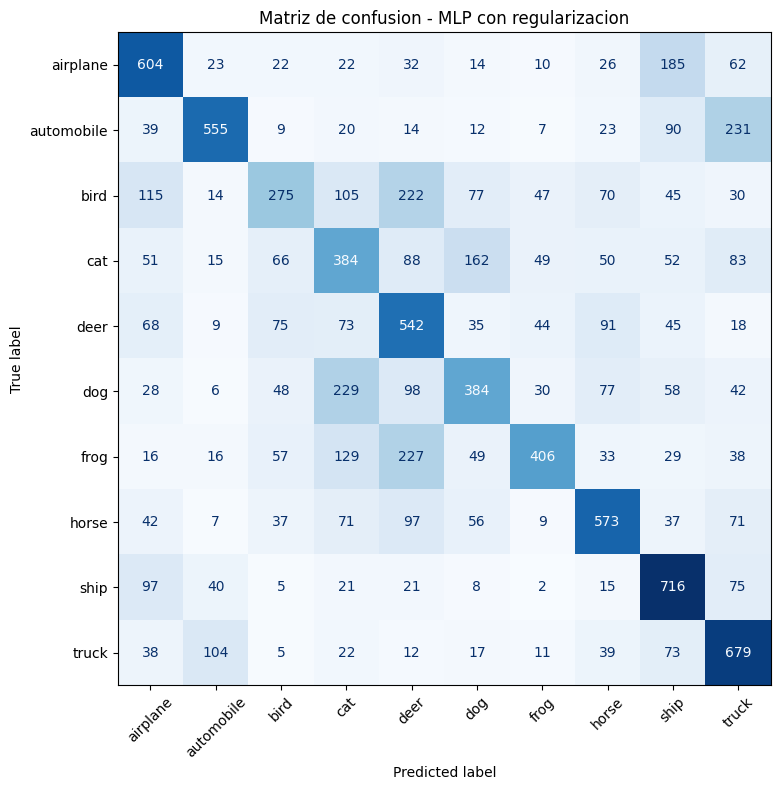

In [26]:
plot_history(history_reg, "MLP con regularizacion")
evaluate_model(model_reg, x_test_mlp, y_test, class_names, "MLP con regularizacion")


## Comparacion final


In [ ]:
def final_metrics_row(model, x_test, y_test, name):
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_w": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall_w": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1_w": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    }

rows = [
    final_metrics_row(model_base, x_test_mlp, y_test, "Sin regularizacion"),
    final_metrics_row(model_reg, x_test_mlp, y_test, "Con regularizacion"),
]

try:
    import pandas as pd
    display(pd.DataFrame(rows).round(4))
except Exception:
    for r in rows:
        print(r)


,Modelo,Accuracy,Precision_w,Recall_w,F1_w,F1_macro
0,Sin regularizacion,0.5041,0.5361,0.5041,0.5048,0.5048
1,Con regularizacion,0.5130,0.5179,0.5130,0.5050,0.5050
